In [25]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

In [26]:
df=pd.read_parquet("CWRU_raw_data_0_load.parquet")

In [28]:
df

,DE_data,fault
0,0.053197,Normal
1,0.088662,Normal
2,0.099718,Normal
3,0.058621,Normal
4,-0.004590,Normal
...,...,...
2071562,-0.500706,21 OR3
2071563,0.090964,21 OR3
2071564,0.375225,21 OR3
2071565,-0.218475,21 OR3


In [29]:
#Encode string level to integer
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['fault'])
num_classes = len(label_encoder.classes_)
print(f"Found {num_classes} unique fault classes: {label_encoder.classes_}")

Found 16 unique fault classes: ['07 B' '07 IR' '07 OR1' '07 OR2' '07 OR3' '14 B' '14 IR' '14 OR' '21 B'
 '21 IR' '21 OR1' '21 OR2' '21 OR3' '28 B' '28 IR' 'Normal']


In [30]:
#Creating window size and segmantation of signals

window_size = 500  # Standard size for motor vibration
step_size = 300     # 50% overlap for data augmentation

X_list = []
y_list = []

In [31]:
# Process each fault type separately so we don't mix signals
for fault_idx in df['label'].unique():
    # Extract the raw signal for this specific fault
    signal = df[df['label'] == fault_idx]['DE_data'].values
    
    # Standardize the signal (crucial when skipping VMD)
    scaler = StandardScaler()
    signal_scaled = scaler.fit_transform(signal.reshape(-1, 1)).flatten()
    
    # Chop the signal into overlapping windows
    for i in range(0, len(signal_scaled) - window_size, step_size):
        window = signal_scaled[i : i + window_size]
        X_list.append(window)
        y_list.append(fault_idx)

In [32]:
# Convert lists to NumPy arrays for the neural network
X = np.array(X_list)
y = np.array(y_list)

# Reshape X to (Samples, Window_Size, Channels) for 1D CNN
X = X.reshape(X.shape[0], X.shape[1], 1)

print(f"Final Input Shape (X): {X.shape} -> (Samples, Time-Steps, Channels)")
print(f"Final Label Shape (y): {y.shape}")

Final Input Shape (X): (6886, 500, 1) -> (Samples, Time-Steps, Channels)
Final Label Shape (y): (6886,)


In [46]:
def build_edge_cnn(input_shape, num_classes):
    model1 = models.Sequential()
    
    # Block 1: Feature Extraction
    model1.add(layers.Conv1D(filters=16, kernel_size=64, strides=2, activation='relu', input_shape=input_shape))
    model1.add(layers.MaxPooling1D(pool_size=2))
    
    # Block 2: Deep Pattern Recognition
    model1.add(layers.Conv1D(filters=32, kernel_size=32, activation='relu'))
    model1.add(layers.MaxPooling1D(pool_size=2))
    
    # Block 3: High-Level Features
    model1.add(layers.Conv1D(filters=64, kernel_size=16, activation='relu'))
    
    # Edge AI Trick: Global Average Pooling instead of Flatten()
    # This removes millions of parameters, keeping the model under 1MB!
    model1.add(layers.GlobalAveragePooling1D())
    
    # Output Layer
    model1.add(layers.Dense(num_classes, activation='softmax'))
    
    # Compile the model
    model1.compile(optimizer='adam', 
                  loss='sparse_categorical_crossentropy', 
                  metrics=['accuracy'])
    return model1

# Instantiate and check the size
edge_model = build_edge_cnn(input_shape=(500, 1), num_classes=num_classes)
edge_model.summary()

e:\Code\Code2\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_15 (Conv1D)              │ (None, 219, 16)        │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_10 (MaxPooling1D) │ (None, 109, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_16 (Conv1D)              │ (None, 78, 32)         │        16,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_11 (MaxPooling1D) │ (None, 39, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_17 (Conv1D)              │ (None, 24, 64)         │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_5      │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │         1,040 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,328 (200.50 KB)

 Trainable params: 51,328 (200.50 KB)

 Non-trainable params: 0 (0.00 B)

Training samples: 5508
Testing samples: 1378

Starting Training Phase...
Epoch 1/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.1823 - loss: 2.5064 - val_accuracy: 0.3338 - val_loss: 2.0045
Epoch 2/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5385 - loss: 1.4680 - val_accuracy: 0.6618 - val_loss: 0.9734
Epoch 3/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7491 - loss: 0.7385 - val_accuracy: 0.7946 - val_loss: 0.5844
Epoch 4/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8181 - loss: 0.5116 - val_accuracy: 0.8403 - val_loss: 0.4350
Epoch 5/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8638 - loss: 0.3863 - val_accuracy: 0.8657 - val_loss: 0.3689
Epoch 6/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8900 - loss: 0.3224 - val_accuracy: 0.8875 - val_loss: 0.3040
Epoch 7/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9036 - loss: 0.2704 - val_accuracy: 0.9042 - val_loss: 0.2684
Epoch 8/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 

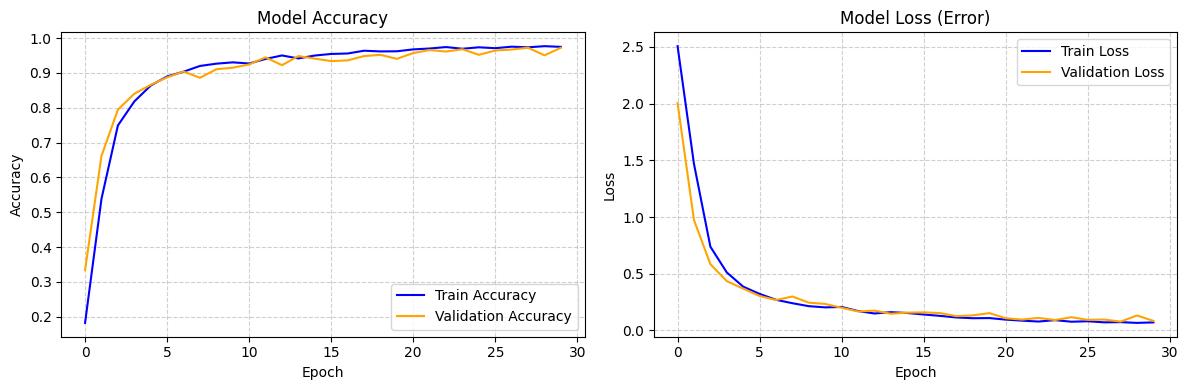

In [47]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# 1. Split the data (80% for training, 20% for testing)
# stratify=y ensures we have the same ratio of 'Normal', 'Inner Race', etc. in both sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

# 2. Define Callbacks (Edge AI Best Practice)
# EarlyStopping prevents the model from memorizing the data (overfitting)
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# 3. Train the Model!
# epochs=30: It will try 30 times, but stop early if it stops improving
# batch_size=32: A good balance for training speed and memory
print("\nStarting Training Phase...")
history = edge_model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=300,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1 # Shows the progress bar
)

# 4. Plot the Training Results
plt.figure(figsize=(12, 4))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Model Loss (Error)')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


Running Inference on Test Set...
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

 AUTOMOTIVE FAULT DETECTION: CLASSIFICATION REPORT
              precision    recall  f1-score   support

        07 B       0.89      0.93      0.91        82
       07 IR       1.00      1.00      1.00        81
      07 OR1       1.00      1.00      1.00        81
      07 OR2       0.98      1.00      0.99        81
      07 OR3       0.96      0.95      0.96        81
        14 B       0.99      0.98      0.98        81
       14 IR       0.99      0.93      0.96        81
       14 OR       0.98      1.00      0.99        81
        21 B       0.91      0.89      0.90        81
       21 IR       1.00      1.00      1.00        81
      21 OR1       1.00      1.00      1.00        81
      21 OR2       0.93      0.91      0.92        82
      21 OR3       0.93      0.95      0.94        81
        28 B       0.99      1.00      0.99        80
       28 IR       1.00      1.00      1.00        80
      Norm

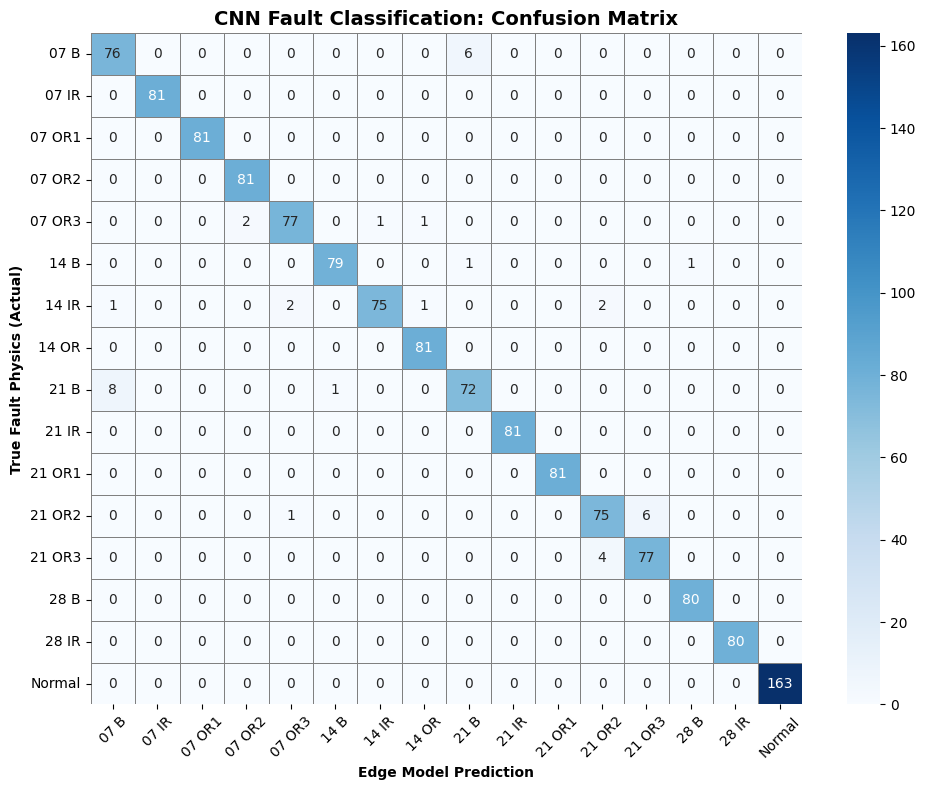

In [48]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np

# 1. Generate Predictions on the Unseen Test Set
print("\nRunning Inference on Test Set...")
# The model outputs probabilities (softmax), so we take the highest probability
y_pred_prob = edge_model.predict(X_test)
y_pred_classes = np.argmax(y_pred_prob, axis=1)

# 2. Print the Detailed Engineering Metrics
# We use the label_encoder's classes to get the actual text names (e.g., 'Normal', 'B007')
target_fault_names = [str(cls) for cls in label_encoder.classes_]

print("\n" + "="*50)
print(" AUTOMOTIVE FAULT DETECTION: CLASSIFICATION REPORT")
print("="*50)
print(classification_report(y_test, y_pred_classes, target_names=target_fault_names))

# 3. Plot the Confusion Matrix
# This generates a beautiful, thesis-ready heatmap
cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_fault_names, 
            yticklabels=target_fault_names,
            linewidths=0.5, linecolor='gray')

plt.title('CNN Fault Classification: Confusion Matrix', fontweight='bold', fontsize=14)
plt.ylabel('True Fault Physics (Actual)', fontweight='bold')
plt.xlabel('Edge Model Prediction', fontweight='bold')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
from tensorflow.keras.models import Model
from sklearn.manifold import TSNE
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

print("\nConfiguring CNN Feature Extractor...")

# 1. Create a "Dummy" Model to extract internal features
# We grab the output of the layer right before the final Dense (Softmax) classification layer.
# In our edge_model, layer[-2] is the GlobalAveragePooling1D layer.
feature_layer = edge_model.layers[-2] 
feature_extractor = model1(inputs=edge_model.input, outputs=feature_layer.output)

# 2. Extract the high-dimensional features from the unseen Test Data
print("Extracting 64-dimensional features from raw vibration windows...")
features_high_dim = feature_extractor.predict(X_test)

# 3. Run t-SNE (Dimensionality Reduction)
# Perplexity=30 is standard for datasets of this size.
print("Running t-SNE to compress features into 2D space (This may take a moment)...")
tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42)
features_2d = tsne.fit_transform(features_high_dim)

# 4. Map the numeric labels back to their actual CWRU file names
# This makes the plot legend readable (e.g., 'Normal', 'B007' instead of 0, 1)
actual_fault_names = label_encoder.inverse_transform(y_test)

# 5. Create a DataFrame for easy Seaborn plotting
tsne_df = pd.DataFrame({
    'TSNE_1': features_2d[:, 0],
    'TSNE_2': features_2d[:, 1],
    'Fault_Type': actual_fault_names
})

# 6. Plot the t-SNE Latent Space
plt.figure(figsize=(12, 9))
sns.scatterplot(
    x='TSNE_1', y='TSNE_2',
    hue='Fault_Type',
    palette='tab20', # Good palette if you have many fault types
    data=tsne_df,
    legend='full',
    alpha=0.7,
    s=40,
    edgecolor=None
)

plt.title('Deep Feature Separation: t-SNE Latent Space Visualization', fontweight='bold', fontsize=15)
plt.xlabel('t-SNE Dimension 1 (Extracted Physics)', fontweight='bold')
plt.ylabel('t-SNE Dimension 2 (Extracted Physics)', fontweight='bold')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="CWRU Faults")
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


Configuring CNN Feature Extractor...


AttributeError: The layer sequential_5 has never been called and thus has no defined input.